In [ ]:
# =================================
# 設定
# =================================
IS_ONLINE_JUDGE = False

LIMIT_QUERY_CNT = None

DEBUG = False
DEBUG_QUERY = None
DEBUG_L = None

MAX_TIME = 1.25
FILE_NUM = 100

# =================================
# 初期化
# =================================
import time

GLOBAL_START_TIME = time.perf_counter()

import random

random.seed(1111)

if IS_ONLINE_JUDGE:
    DEBUG = False

# =================================
# Import
# =================================
import math
from collections import defaultdict

# =================================
# 共通
# =================================
if True:
    from importlib import reload

    import src.common as common

    reload(common)


from src.common import (
    Env,
    EnvOffline,
    calc_dist,
    construct_dist_matrix,
    construct_graph,
    construct_graph_from_edges,
    cut_graph,
    exponential_schedule,
    prim_k,
    sort_pair,
)


# =================================
# 汎用（main.py専用）
# =================================
def debug_print(*args, **kwargs):
    if IS_ONLINE_JUDGE:
        return
    print(*args, **kwargs)


def print_elapsed_time():
    debug_print(f"elapsed time: {(time.perf_counter() - GLOBAL_START_TIME) * 1000:.2f}msecs")

In [237]:
file_num = 62
input_file_path = f"../in/{file_num:04d}.txt"
output_file_path = f"../out/{file_num:04d}.txt"
env = EnvOffline(input_file_path, output_file_path)

In [ ]:
def cost_formula(d1: int, d2: int) -> int:
    if d1 > d2:
        return d1 - d2
    else:
        return 0


def calc_init_cost(
    constrains: list[tuple[tuple[int, int], tuple[int, int]]],
    x: list[tuple[int, int]],
) -> tuple[list[int], int]:
    cost_list: list[int] = [0 for _ in range(len(constrains))]
    for ci in range(len(constrains)):
        cons = constrains[ci]
        (p1, p2), (q1, q2) = cons
        dist1 = calc_dist(x[p1], x[p2])
        dist2 = calc_dist(x[q1], x[q2])
        cost_list[ci] = cost_formula(dist1, dist2)
    total_cost = sum(cost_list)
    return cost_list, total_cost


def calc_cost(
    constrains: list[tuple[tuple[int, int], tuple[int, int]]],
    x_now: list[tuple[int, int]],
    x_update: dict[int, tuple[int, int]],
    cost_list: list[int],
    cost_now: int,
    vid_to_constid: dict[int, list[int]],
) -> tuple[dict[int, int], int]:
    new_cost = cost_now
    cost_update = dict()
    for v in x_update:
        for consid in vid_to_constid[v]:
            (p1, p2), (q1, q2) = constrains[consid]
            coord1 = x_update[p1] if p1 in x_update else x_now[p1]
            coord2 = x_update[p2] if p2 in x_update else x_now[p2]
            coord3 = x_update[q1] if q1 in x_update else x_now[q1]
            coord4 = x_update[q2] if q2 in x_update else x_now[q2]
            dist1 = calc_dist(coord1, coord2)
            dist2 = calc_dist(coord3, coord4)
            pre_cost = cost_list[consid]
            now_cost = cost_formula(dist1, dist2)
            new_cost += now_cost - pre_cost
            cost_update[consid] = now_cost
    return cost_update, new_cost


def neighbor(
    x: list[tuple[int, int]],
    target_v: list[int],
    rects: list[list[int]],
    now_mul_x: float,
    k: int = 1,
):
    vs: list[int] = random.sample(target_v, k=k)
    x_update: dict[int, tuple[int, int]] = dict()

    for v in vs:
        rnd = random.random()
        rand_coord = tuple()
        if rnd < 0.99:
            x1, x2, y1, y2 = rects[v]
            nx, ny = x[v]
            dx = x2 - x1
            dy = y2 - y1
            max_dx = max(int(dx * now_mul_x), 1)
            max_dy = max(int(dy * now_mul_x), 1)
            lim_l = max(x1, nx - max_dx)
            lim_r = min(x2, nx + max_dx)
            lim_u = max(y1, ny - max_dy)
            lim_d = min(y2, ny + max_dy)
            rand_coord = random.randint(lim_l, lim_r), random.randint(lim_u, lim_d)
        else:
            x1, x2, y1, y2 = rects[v]
            rand_coord = random.randint(x1, x2), random.randint(y1, y2)

        x_update[v] = rand_coord
        nx, ny = x[v]
        x1, x2, y1, y2 = rects[v]
        mul_x = abs(nx - rand_coord[0]) / (x2 - x1)

    return x_update, mul_x

In [ ]:
def simulated_annealing(
    x0: list[tuple[int, int]],
    t0: float,
    t1: float,
    constrains: list[tuple[tuple[int, int], tuple[int, int]]],
    rectangles: list[tuple[int, int, int, int]],
    target_vs: list[int],
    vid_to_constid: dict[int, list[int]],
    max_time: float = 1.0,
    display: bool = False,
):
    x = x0.copy()
    x_best = x
    x_update = dict()

    cost_list, cost_current = calc_init_cost(constrains, x)
    cost_best = cost_current
    cost_update = dict()

    simulate_cnt = 0
    good_cnt = 0
    st = time.perf_counter()

    sum_mul_x = 0.0
    now_mul_x = 0.5
    while True:
        elapsed_time = time.perf_counter() - st
        if elapsed_time >= max_time:
            break
        temp = exponential_schedule(t0, t1, elapsed_time, max_time)

        x_update, mul_x = neighbor(x, target_vs, rectangles, now_mul_x)
        cost_update, cost_new = calc_cost(
            constrains=constrains,
            x_now=x,
            x_update=x_update,
            cost_list=cost_list,
            cost_now=cost_current,
            vid_to_constid=vid_to_constid,
        )

        delta_cost = cost_new - cost_current
        if delta_cost < 0:
            good_cnt += 1
            # _dist_diffs.append(_dist_diff)
            sum_mul_x += mul_x
        if delta_cost <= 0 or random.random() < math.exp(-delta_cost / temp):
            cost_current = cost_new
            for v in x_update:
                x[v] = x_update[v]
            for ci in cost_update:
                cost_list[ci] = cost_update[ci]
        if cost_current < cost_best:
            x_best = x
            cost_best = cost_current

        simulate_cnt += 1
        if display and simulate_cnt % 5000 == 0:
            debug_print(
                f"i: {simulate_cnt}, cost_now: {cost_current}, best_cost: {cost_best}, temp: {temp:.2f}, good_cnt: {good_cnt}/{simulate_cnt}"
            )
        if good_cnt > 0 and good_cnt % 100 == 0:
            now_mul_x = max(min(0.01, sum_mul_x / good_cnt), 0.5)
            sum_mul_x = 0.0
    return x_best, cost_best

In [240]:
all_graph = construct_graph({i: p for i, p in enumerate(env.cneter_points)})

max_d_list = []
for i, (l, r, t, b) in enumerate(env.rectangles):
    dx = r - l
    dy = b - t
    max_d_list.append((i, dx + dy))  # あえて辺の合計にする
max_d_list.sort(key=lambda x: x[1], reverse=True)

# longs_points = [i for i, d in max_d_list[200:]]

constrains = set()
random_vs = set()
for big_v, _ in max_d_list[: env.Q]:
    other_points = all_graph[big_v][: env.L * 2]
    other_points = [p for d, p in other_points]
    other_points = sorted(other_points, key=lambda x: max_d_list[x], reverse=True)
    other_points = other_points[: env.L - 1]

    tmp_random_vs = [big_v] + other_points

    edges = env.query(tmp_random_vs)
    graph = construct_graph_from_edges(edges, tmp_random_vs)

    for e in edges:
        group_vs1, group_vs2 = cut_graph(graph, e)
        for v1 in group_vs1:
            for v2 in group_vs2:
                sv1, sv2 = sort_pair((v1, v2))
                if e == (sv1, sv2):
                    continue
                constrains.add((e, (sv1, sv2)))
                if DEBUG:
                    long_c1 = env.coordinates[sv1]
                    long_c2 = env.coordinates[sv2]
                    short_c1 = env.coordinates[e[0]]
                    short_c2 = env.coordinates[e[1]]
                    dist1 = calc_dist(short_c1, short_c2)
                    dist2 = calc_dist(long_c1, long_c2)
                    if dist1 > dist2:
                        debug_print((dist1, dist2), e, (sv1, sv2))
                    assert dist1 <= dist2
    random_vs.update(tmp_random_vs)
constrains = list(constrains)
random_vs = list(random_vs)

vid_to_constid = defaultdict(set)
for i, const in enumerate(constrains):
    (p1, p2), (q1, q2) = const
    vid_to_constid[p1].add(i)
    vid_to_constid[p2].add(i)
    vid_to_constid[q1].add(i)
    vid_to_constid[q2].add(i)

In [241]:
# 辺の長さ最大 3000 / 4 * 800 = 10^6 ぐらい変化しそう。

x_bests = []
for _ in range(1):
    x_best, cost_best = simulated_annealing(
        x0=env.cneter_points,
        t0=10.0,
        t1=1.0,
        constrains=constrains,
        rectangles=env.rectangles,
        target_vs=random_vs,
        vid_to_constid=vid_to_constid,
        max_time=30,
        display=True,
    )
    x_bests.append(x_best)

i: 5000, cost_now: 457451, best_cost: 457451, temp: 8.65, good_cnt: 1176/5000
i: 10000, cost_now: 115602, best_cost: 115592, temp: 7.61, good_cnt: 1764/10000
i: 15000, cost_now: 60188, best_cost: 60188, temp: 6.70, good_cnt: 2149/15000
i: 20000, cost_now: 34723, best_cost: 34723, temp: 5.95, good_cnt: 2432/20000
i: 25000, cost_now: 22236, best_cost: 22236, temp: 5.29, good_cnt: 2643/25000
i: 30000, cost_now: 16153, best_cost: 16153, temp: 4.71, good_cnt: 2796/30000
i: 35000, cost_now: 11171, best_cost: 11171, temp: 4.20, good_cnt: 2928/35000
i: 40000, cost_now: 9551, best_cost: 9551, temp: 3.75, good_cnt: 3014/40000
i: 45000, cost_now: 7895, best_cost: 7895, temp: 3.35, good_cnt: 3109/45000
i: 50000, cost_now: 6742, best_cost: 6742, temp: 2.97, good_cnt: 3189/50000
i: 55000, cost_now: 5347, best_cost: 5347, temp: 2.65, good_cnt: 3249/55000
i: 60000, cost_now: 4156, best_cost: 4156, temp: 2.38, good_cnt: 3321/60000
i: 65000, cost_now: 3220, best_cost: 3220, temp: 2.12, good_cnt: 3376/65

In [242]:
x_best_mean = [tuple() for _ in range(env.N)]
for i in range(env.N):
    total_x = 0
    total_y = 0
    for j in range(len(x_bests)):
        total_x += x_bests[j][i][0]
        total_y += x_bests[j][i][1]
    total_x //= len(x_bests)
    total_y //= len(x_bests)
    x_best_mean[i] = (total_x, total_y)

In [243]:
def calc_greedy_answer(env: Env, target_points):
    graph = construct_dist_matrix(target_points)

    groups = [(i, g) for i, g in enumerate(env.G)]
    groups = sorted(groups, key=lambda x: x[1], reverse=True)

    ans_edges = [None for _ in range(len(groups))]
    ans_v = [None for _ in range(len(groups))]
    ans_costs = [None for _ in range(len(groups))]

    now_used: set = set()
    not_used: set = set(range(env.N))
    for group_n, group_size in groups:
        v = not_used.pop()
        prim_edges, prim_v, prim_cost = prim_k(graph, v, group_size, now_used, env.N)
        ans_edges[group_n] = prim_edges
        ans_v[group_n] = prim_v
        ans_costs[group_n] = prim_cost
        now_used.update(prim_v)
        not_used.difference_update(prim_v)

    return ans_v, ans_edges, ans_costs

In [244]:
ans_v, ans_edges, _ = calc_greedy_answer(env, x_best_mean)
env.answer(ans_v, ans_edges)

query: 400


253179.0

In [245]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

In [246]:
# print("min_cost", min(simulate_costs))
# # cost_bin = sorted(simulate_costs)[1000]
# cost_bin = 0
# print(cost_bin)
# bin_inds = [i for i, c in enumerate(simulate_costs) if c <= cost_bin]
# min_cost_points = [simulate_points[i] for i in bin_inds]

# plt.figure(figsize=(10, 10))
# plt.hist(simulate_costs, bins=100)
# plt.show()

In [247]:
def get_color(i):
    # colors = list(matplotlib.colors.CSS4_COLORS.values())
    colors = matplotlib.cm.tab20.colors
    return colors[i % len(colors)]


def draw():
    # corrects_np = np.array(env.coordinates)[random_vs]
    # estimates_np = np.array([min_cost_points[i] for i in random_vs])
    # rectangles = np.array([env.rectangles[i] for i in range(env.N)])[random_vs]

    # 四角形と、四角形内の正解点と予測点を描画
    # plt.figure(figsize=(10, 10))
    # ax = plt.gca()
    for v in random_vs[:10]:
        plt.figure(figsize=(5, 5))
        ax = plt.gca()
        color = get_color(v)
        rect = env.rectangles[v]
        l, r, t, b = rect

        ax.add_patch(matplotlib.patches.Rectangle((l, t), r - l, b - t, alpha=1, color=color, fill=False))
        p1 = env.coordinates[v]
        # p2 = estimates_np[i]
        # x = [p1[0], p2[0]]
        # y = [p1[1], p2[1]]
        # ax.plot(x, y, color=color, alpha=0.3)
        plt.scatter(p1[0], p1[1], color="red", alpha=1, label=f"correct {v}", s=100)
        x, y = [], []
        for v_list in [x_best]:
            p2 = v_list[v]
            x.append(p2[0])
            y.append(p2[1])
        plt.scatter(x, y, color=color, alpha=1, label=f"estimate {v}", marker="x", s=20)
        plt.show()


# draw()

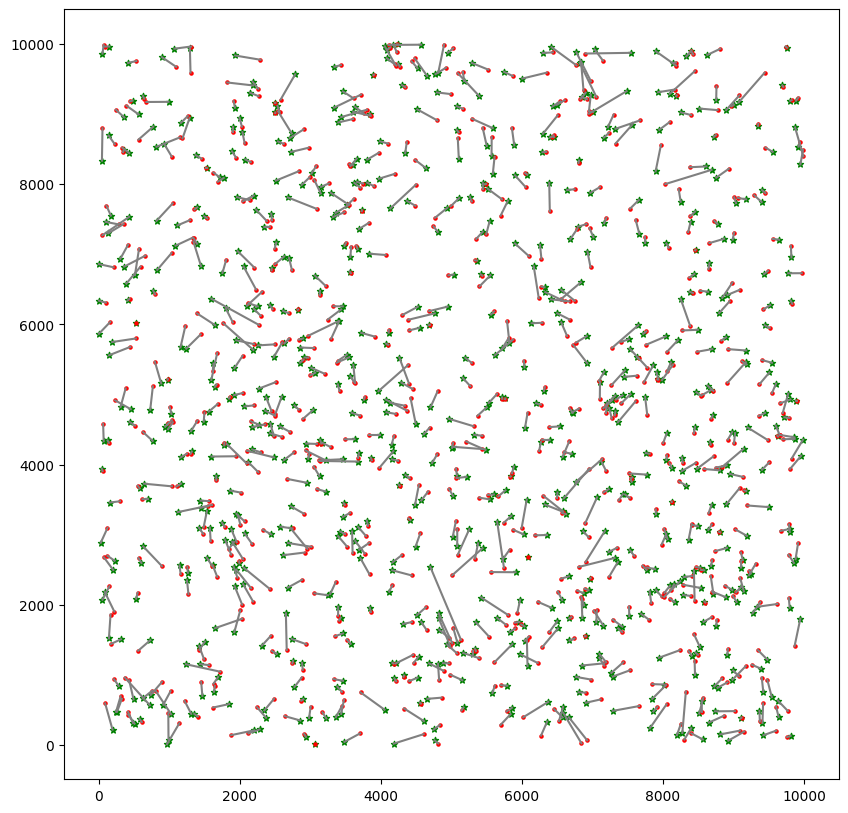

In [248]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

point_inds = list(range(env.N))  # longs_points[:]
corrects_np = np.array(env.coordinates)[point_inds]
estimates_np = np.array(x_best)[point_inds]
rectangles = np.array([env.rectangles[i] for i in range(env.N)])[point_inds]

# 四角形と、四角形内の正解点と予測点を描画
plt.figure(figsize=(10, 10))
ax = plt.gca()
# for i, rect in enumerate(rectangles):
#     l, r, t, b = rect
#     ax.add_patch(matplotlib.patches.Rectangle((l, t), r - l, b - t, alpha=0.1))
ax.scatter(corrects_np[:, 0], corrects_np[:, 1], color="green", label="correct", s=20, marker="*")
ax.scatter(estimates_np[:, 0], estimates_np[:, 1], color="red", label="estimate", s=5, marker="o")
for point_ind in range(len(corrects_np)):
    ax.plot(
        (corrects_np[point_ind, 0], estimates_np[point_ind, 0]),
        (corrects_np[point_ind, 1], estimates_np[point_ind, 1]),
        color="gray",
        label="correct path",
    )
plt.show()

In [249]:
# import networkx as nx

# nx_graph = nx.Graph(graph)
# nx.draw(nx_graph, with_labels=True)


In [250]:
# import numpy as np

# corrects = np.array([env.coordinates[i] for i in range(env.N)])
# estimates = np.array([estimate_points[i].estimate_coordinate for i in range(env.N)])
# centers = np.array([env.cneter_points[i] for i in range(env.N)])

# print("base:", calc_point_avg_distances(corrects, centers))
# print("opt", calc_point_avg_distances(corrects, estimates))

# anv_v, ans_edges = calc_greedy_answer(env, corrects)
# print("best", env.answer(anv_v, ans_edges))

# anv_v, ans_edges = update_mst(env, *calc_greedy_answer(env, estimates), define_query_cnt(env, limit_query_cnt=None))
# print("estimate", env.answer(anv_v, ans_edges))

# anv_v, ans_edges = update_mst(env, *calc_greedy_answer(env, centers), define_query_cnt(env, limit_query_cnt=None))
# print("base", env.answer(anv_v, ans_edges))

In [251]:
# import matplotlib
# import matplotlib.pyplot as plt
# import numpy as np

# point_inds = list(range(env.N))  # longs_points[:]
# corrects_np = np.array(corrects)[point_inds]
# estimates_np = np.array(estimates)[point_inds]
# rectangles = np.array([env.rectangles[i] for i in range(env.N)])[point_inds]

# # 四角形と、四角形内の正解点と予測点を描画
# plt.figure(figsize=(10, 10))
# ax = plt.gca()
# # for i, rect in enumerate(rectangles):
# #     l, r, t, b = rect
# #     ax.add_patch(matplotlib.patches.Rectangle((l, t), r - l, b - t, alpha=0.1))
# ax.scatter(corrects_np[:, 0], corrects_np[:, 1], color="green", label="correct", s=20, marker="*")
# ax.scatter(estimates_np[:, 0], estimates_np[:, 1], color="red", label="estimate", s=5, marker="o")
# for point_ind in range(len(corrects_np)):
#     ax.plot(
#         (corrects_np[point_ind, 0], estimates_np[point_ind, 0]),
#         (corrects_np[point_ind, 1], estimates_np[point_ind, 1]),
#         color="gray",
#         label="correct path",
#     )
# plt.show()